# 🧬 DermRL — Experiment 1: DQN (Value-Based)
### SkinConditionEnv | Deep Q-Network | 10 Hyperparameter Experiments

DQN is a **value-based** method. It learns a Q-function Q(s,a) — the expected return for taking action *a* in state *s*. The policy is implicit: always pick the action with the highest Q-value (ε-greedy during training).

**Key hyperparameters explored:**
- Learning rate, buffer size, batch size, gamma (discount)
- Epsilon schedule (exploration), target network update frequency
- Network architecture depth

---
*Runtime: T4 GPU recommended · ~30–40 min for all 10 experiments*

## 1 · Install & Imports

In [ ]:
%%capture
!pip install stable-baselines3[extra] gymnasium torch matplotlib pandas seaborn

In [ ]:
import os, sys, json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import torch
from stable_baselines3 import DQN
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.callbacks import EvalCallback

PROJECT_ROOT = '/content/skin_rl_project'
os.makedirs(f'{PROJECT_ROOT}/environment', exist_ok=True)
os.makedirs(f'{PROJECT_ROOT}/models/dqn', exist_ok=True)
sys.path.insert(0, PROJECT_ROOT)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
print(f'PyTorch: {torch.__version__}')

Device: cuda
PyTorch: 2.10.0+cu128


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 2 · Write Environment

In [ ]:
ENV_CODE = '''
from __future__ import annotations
import gymnasium as gym
from gymnasium import spaces
import numpy as np
from typing import Optional, List, Dict

MAX_DAYS        = 90
IMPROVEMENT_THR = 0.35
WORSENING_THR   = 0.90

ACTION_LABELS = [
    "Do Nothing", "Exercise / Sports", "Vitamin Supplements", "Improve Diet",
    "Change Skincare Routine", "Prescribed Pills", "Topical Treatment", "Reduce Sun / Apply SPF",
]

ACTION_EFFECTS = {
    0: np.array([ 0.04,  0.02, -0.02,  0.01,  0.03, -0.02]),
    1: np.array([-0.03, -0.02, -0.01,  0.00, -0.08,  0.03]),
    2: np.array([-0.02, -0.01,  0.04,  0.00, -0.01,  0.02]),
    3: np.array([-0.04, -0.02,  0.02,  0.00, -0.01,  0.08]),
    4: np.array([-0.03, -0.03,  0.06,  0.00,  0.00,  0.01]),
    5: np.array([-0.10, -0.08,  0.01,  0.00, -0.01,  0.01]),
    6: np.array([-0.06, -0.05,  0.01,  0.00,  0.00,  0.00]),
    7: np.array([-0.01, -0.01,  0.02, -0.06,  0.00,  0.00]),
}
ACTION_NOISE = {0: 0.03, 1: 0.02, 2: 0.02, 3: 0.02, 4: 0.02, 5: 0.04, 6: 0.03, 7: 0.01}


class SkinConditionEnv(gym.Env):
    metadata = {"render_modes": ["human", "rgb_array", "none"], "render_fps": 4}

    def __init__(self, render_mode: str = "none", seed=None):
        super().__init__()
        self.render_mode = render_mode
        self._rng = np.random.default_rng(seed)
        self.observation_space = spaces.Box(
            low=np.zeros(7, dtype=np.float32),
            high=np.ones(7, dtype=np.float32), dtype=np.float32)
        self.action_space = spaces.Discrete(len(ACTION_LABELS))
        self._state: np.ndarray = np.zeros(6, dtype=np.float64)
        self._day: int = 0
        self._history: List[Dict] = []

    def _get_obs(self) -> np.ndarray:
        return np.append(self._state, self._day / MAX_DAYS).astype(np.float32)

    def _get_info(self, action: int = -1) -> dict:
        return {
            "day": self._day, "action": action,
            "severity":     float(self._state[0]),
            "inflammation": float(self._state[1]),
            "hydration":    float(self._state[2]),
            "sun_damage":   float(self._state[3]),
            "stress":       float(self._state[4]),
            "diet_quality": float(self._state[5]),
        }

    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)
        if seed is not None:
            self._rng = np.random.default_rng(seed)
        self._episode_variant = int(self._rng.integers(0, 3))
        self._day = 0
        self._history = []
        if self._episode_variant == 0:
            self._state = self._rng.uniform(
                [0.30, 0.25, 0.40, 0.10, 0.30, 0.50],
                [0.50, 0.40, 0.60, 0.25, 0.50, 0.70])
        elif self._episode_variant == 1:
            self._state = self._rng.uniform(
                [0.50, 0.45, 0.25, 0.20, 0.50, 0.30],
                [0.70, 0.60, 0.40, 0.40, 0.70, 0.50])
        else:
            self._state = self._rng.uniform(
                [0.70, 0.65, 0.10, 0.30, 0.65, 0.15],
                [0.90, 0.85, 0.25, 0.55, 0.85, 0.35])
        self._history.append(self._get_info())
        return self._get_obs(), self._get_info()

    def step(self, action: int):
        if not self.action_space.contains(action):
            raise ValueError(f"Invalid action {action}")
        self._day += 1
        delta = ACTION_EFFECTS[action].copy()
        noise = self._rng.normal(0, ACTION_NOISE[action], size=6)
        self._state = np.clip(self._state + delta + noise, 0.0, 1.0)
        severity     = self._state[0]
        inflammation = self._state[1]
        composite    = 0.6 * severity + 0.3 * inflammation + 0.1 * self._state[3]
        prev_severity = self._history[-1]["severity"] if self._history else severity
        improvement   = prev_severity - severity
        reward  = improvement * 10.0 - 0.1
        reward += (self._state[2] - 0.5) * 0.5   # hydration bonus
        reward += (self._state[5] - 0.5) * 0.5   # diet quality bonus
        reward -= self._state[4] * 0.3            # stress penalty
        terminated = truncated = False
        if composite < IMPROVEMENT_THR:
            reward += 20.0; terminated = True
        elif composite >= WORSENING_THR:
            reward -= 15.0; terminated = True
        elif self._day >= MAX_DAYS:
            reward += max(0, (0.7 - severity) * 10); truncated = True
        self._history.append(self._get_info(action))
        if self.render_mode == "human": self.render()
        return self._get_obs(), float(reward), terminated, truncated, self._get_info(action)

    def render(self): pass
    def close(self): pass

    @property
    def history(self): return list(self._history)
'''
with open(f'{PROJECT_ROOT}/environment/custom_env.py', 'w') as f: f.write(ENV_CODE)
print('Environment written: SkinConditionEnv with 7-obs, 8-action space')
print(f'  State: severity, inflammation, hydration, sun_damage, stress, diet_quality, day_norm')
print(f'  Actions: {8} (Do Nothing, Exercise, Vitamins, Diet, Skincare, Pills, Topical, SPF)')
print(f'  Episode length: {90} days | Improvement threshold: <0.35 composite')


Environment written: SkinConditionEnv with 7-obs, 8-action space
  State: severity, inflammation, hydration, sun_damage, stress, diet_quality, day_norm
  Actions: 8 (Do Nothing, Exercise, Vitamins, Diet, Skincare, Pills, Topical, SPF)
  Episode length: 90 days | Improvement threshold: <0.35 composite


In [ ]:
from environment.custom_env import SkinConditionEnv
env = SkinConditionEnv(render_mode='none')
obs, info = env.reset()
print('Obs shape:', obs.shape, '| Actions:', env.action_space.n)
print('Initial severity:', f"{info['severity']:.1%}")
env.close()
print('✅ Environment OK')

Obs shape: (7,) | Actions: 8
Initial severity: 80.2%
✅ Environment OK


## 3 · Experiment Configurations

The 10 experiments systematically vary:
- **LR**: tests sensitivity to step size (too high → divergence, too low → slow convergence)
- **Buffer**: small buffers cause correlated updates; large buffers improve stability
- **Batch size**: larger = more stable gradients but slower per-step
- **Gamma**: how far-sighted the agent is (low γ = myopic)
- **Epsilon schedule**: controls exploration/exploitation tradeoff
- **Target update**: how often the stable Q-target is refreshed
- **Net architecture**: capacity of the function approximator

In [ ]:
EXPERIMENTS = [
    {
        "id": 1,
        "name": "Baseline",
        "desc": "Standard DQN reference point. Moderate LR, medium buffer, default epsilon decay.",
        "config": dict(learning_rate=1e-3, buffer_size=50_000, batch_size=64, gamma=0.99,
                       train_freq=4, gradient_steps=1, target_update_interval=500,
                       exploration_fraction=0.20, exploration_final_eps=0.05,
                       policy_kwargs=dict(net_arch=[64, 64]))
    },
    {
        "id": 2,
        "name": "High LR",
        "desc": "LR=5e-3: faster early learning but risks instability and overshooting Q-values.",
        "config": dict(learning_rate=5e-3, buffer_size=50_000, batch_size=64, gamma=0.99,
                       train_freq=4, gradient_steps=1, target_update_interval=500,
                       exploration_fraction=0.20, exploration_final_eps=0.05,
                       policy_kwargs=dict(net_arch=[64, 64]))
    },
    {
        "id": 3,
        "name": "Low LR",
        "desc": "LR=1e-4: slow but stable convergence. Good for fine-tuning later stages.",
        "config": dict(learning_rate=1e-4, buffer_size=50_000, batch_size=64, gamma=0.99,
                       train_freq=4, gradient_steps=1, target_update_interval=500,
                       exploration_fraction=0.20, exploration_final_eps=0.05,
                       policy_kwargs=dict(net_arch=[64, 64]))
    },
    {
        "id": 4,
        "name": "Large Buffer",
        "desc": "Buffer=200k: more diverse replay, less correlated updates, more stable training.",
        "config": dict(learning_rate=1e-3, buffer_size=200_000, batch_size=64, gamma=0.99,
                       train_freq=4, gradient_steps=1, target_update_interval=500,
                       exploration_fraction=0.20, exploration_final_eps=0.05,
                       policy_kwargs=dict(net_arch=[64, 64]))
    },
    {
        "id": 5,
        "name": "Small Buffer",
        "desc": "Buffer=5k: fast turnover of experiences but high correlation. Expect instability.",
        "config": dict(learning_rate=1e-3, buffer_size=5_000, batch_size=64, gamma=0.99,
                       train_freq=4, gradient_steps=1, target_update_interval=500,
                       exploration_fraction=0.20, exploration_final_eps=0.05,
                       policy_kwargs=dict(net_arch=[64, 64]))
    },
    {
        "id": 6,
        "name": "Low Gamma",
        "desc": "γ=0.85: myopic agent. Prioritises immediate reward, ignores long-term skin clearing.",
        "config": dict(learning_rate=1e-3, buffer_size=50_000, batch_size=64, gamma=0.85,
                       train_freq=4, gradient_steps=1, target_update_interval=500,
                       exploration_fraction=0.20, exploration_final_eps=0.05,
                       policy_kwargs=dict(net_arch=[64, 64]))
    },
    {
        "id": 7,
        "name": "High Gamma",
        "desc": "γ=0.999: far-sighted agent. Plans over full 90-day horizon. Risk: slow credit assignment.",
        "config": dict(learning_rate=1e-3, buffer_size=50_000, batch_size=64, gamma=0.999,
                       train_freq=4, gradient_steps=1, target_update_interval=500,
                       exploration_fraction=0.20, exploration_final_eps=0.05,
                       policy_kwargs=dict(net_arch=[64, 64]))
    },
    {
        "id": 8,
        "name": "More Exploration",
        "desc": "ε-final=0.20, fraction=0.40: keeps exploring longer. Useful in stochastic environments.",
        "config": dict(learning_rate=1e-3, buffer_size=50_000, batch_size=64, gamma=0.99,
                       train_freq=4, gradient_steps=1, target_update_interval=500,
                       exploration_fraction=0.40, exploration_final_eps=0.20,
                       policy_kwargs=dict(net_arch=[64, 64]))
    },
    {
        "id": 9,
        "name": "Deeper Network",
        "desc": "3 hidden layers [256,256,256]: higher capacity, can model complex Q-landscapes.",
        "config": dict(learning_rate=1e-3, buffer_size=50_000, batch_size=128, gamma=0.99,
                       train_freq=4, gradient_steps=1, target_update_interval=500,
                       exploration_fraction=0.20, exploration_final_eps=0.05,
                       policy_kwargs=dict(net_arch=[256, 256, 256]))
    },
    {
        "id": 10,
        "name": "Frequent Target Update + Large Batch",
        "desc": "target_update=100, batch=256: very stable Q-targets with high-quality gradient estimates.",
        "config": dict(learning_rate=1e-3, buffer_size=100_000, batch_size=256, gamma=0.99,
                       train_freq=4, gradient_steps=2, target_update_interval=100,
                       exploration_fraction=0.20, exploration_final_eps=0.05,
                       policy_kwargs=dict(net_arch=[128, 128]))
    },
]
print(f'Loaded {len(EXPERIMENTS)} experiment configurations.')
for e in EXPERIMENTS:
    print(f"  Exp {e['id']:2d}: {e['name']}")

Loaded 10 experiment configurations.
  Exp  1: Baseline
  Exp  2: High LR
  Exp  3: Low LR
  Exp  4: Large Buffer
  Exp  5: Small Buffer
  Exp  6: Low Gamma
  Exp  7: High Gamma
  Exp  8: More Exploration
  Exp  9: Deeper Network
  Exp 10: Frequent Target Update + Large Batch


## 4 · Training Loop

In [ ]:
from stable_baselines3.common.callbacks import BaseCallback, EvalCallback
import warnings; warnings.filterwarnings('ignore')

class TDLossCallback(BaseCallback):
    # Records TD loss and episode rewards for learning curve plots
    def __init__(self):
        super().__init__()
        self.td_losses       = []
        self.episode_rewards = []
        self._ep_r = 0.0
    def _on_step(self):
        self._ep_r += self.locals['rewards'][0]
        if self.locals['dones'][0]:
            self.episode_rewards.append(self._ep_r)
            self._ep_r = 0.0
        if self.model.logger and hasattr(self.model.logger, 'name_to_value'):
            loss = self.model.logger.name_to_value.get('train/loss', None)
            if loss is not None:
                self.td_losses.append(float(loss))
        return True

from stable_baselines3.common.callbacks import CallbackList

TOTAL_STEPS = 150_000
results = []

for exp in EXPERIMENTS:
    print(f"\n{'='*60}")
    print(f"Exp {exp['id']:2d}/10: {exp['name']}")
    print(f"  -> {exp['desc']}")
    print(f"{'='*60}")

    save_dir = f"{PROJECT_ROOT}/models/dqn/exp_{exp['id']:02d}"
    os.makedirs(save_dir, exist_ok=True)

    # FIX 2: unique seed per experiment (was seed=42 for training, seed=99 for eval)
    exp_seed = exp['id'] * 13

    train_env = Monitor(SkinConditionEnv(render_mode='none'))
    # FIX 2: eval env seed differs per experiment
    eval_env  = Monitor(SkinConditionEnv(render_mode='none', seed=exp_seed))

    eval_cb = EvalCallback(eval_env, best_model_save_path=save_dir,
                           log_path=save_dir, eval_freq=10_000,
                           n_eval_episodes=10, deterministic=True, verbose=0)
    td_cb = TDLossCallback()

    model = DQN('MlpPolicy', train_env, verbose=0, device=DEVICE,
                learning_starts=1000, **exp['config'])

    t0 = time.time()
    model.learn(total_timesteps=TOTAL_STEPS,
                callback=CallbackList([eval_cb, td_cb]),
                progress_bar=True)
    elapsed = time.time() - t0

    # FIX 2: final eval env also uses exp_seed+500 (unique per exp)
    eval_env2 = Monitor(SkinConditionEnv(render_mode='none', seed=exp_seed + 500))
    mean_r, std_r = evaluate_policy(model, eval_env2, n_eval_episodes=20, deterministic=True)

    successes = 0
    for _ in range(50):
        obs, _ = eval_env2.reset()
        done = False
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, _, term, trunc, info = eval_env2.step(int(action))
            done = term or trunc
        if info.get('severity', 1.0) < 0.35:
            successes += 1

    result = {
        'exp_id':        exp['id'],
        'name':          exp['name'],
        'mean_reward':   round(mean_r, 2),
        'std_reward':    round(std_r, 2),
        'success_rate':  round(successes / 50 * 100, 1),
        'train_time_s':  round(elapsed, 1),
        'lr':            exp['config']['learning_rate'],
        'buffer':        exp['config']['buffer_size'],
        'batch':         exp['config']['batch_size'],
        'gamma':         exp['config']['gamma'],
        'eps_final':     exp['config']['exploration_final_eps'],
        'target_upd':    exp['config']['target_update_interval'],
        'net_arch':      str(exp['config']['policy_kwargs']['net_arch']),
        'td_losses':     td_cb.td_losses,
        'ep_rewards':    td_cb.episode_rewards,
    }
    results.append(result)
    print(f"  Mean reward: {mean_r:.2f} +/-{std_r:.2f} | Success: {successes}/50 | Time: {elapsed/60:.1f}min")
    train_env.close(); eval_env.close(); eval_env2.close()

print('\nAll DQN experiments complete!')



Exp  1/10: Baseline
  -> Standard DQN reference point. Moderate LR, medium buffer, default epsilon decay.


Output()

Output()

  Mean reward: 13.28 +/-7.49 | Success: 6/50 | Time: 3.8min

Exp  2/10: High LR
  -> LR=5e-3: faster early learning but risks instability and overshooting Q-values.


Output()

...

Output()

  Mean reward: 10.59 +/-8.05 | Success: 16/50 | Time: 3.3min

Exp  9/10: Deeper Network
  -> 3 hidden layers [256,256,256]: higher capacity, can model complex Q-landscapes.


Output()

  Mean reward: 19.80 +/-5.22 | Success: 19/50 | Time: 4.0min

Exp 10/10: Frequent Target Update + Large Batch
  -> target_update=100, batch=256: very stable Q-targets with high-quality gradient estimates.


  Mean reward: 18.05 +/-8.82 | Success: 10/50 | Time: 5.5min

All DQN experiments complete!


## 5 · Results Table

In [ ]:
df = pd.DataFrame(results)
df = df.sort_values('mean_reward', ascending=False).reset_index(drop=True)

display_cols = ['exp_id','name','lr','buffer','batch','gamma','eps_final',
                'target_upd','net_arch','mean_reward','std_reward','success_rate','train_time_s']
df_display = df[display_cols].copy()
df_display.columns = ['#','Experiment','LR','Buffer','Batch','γ','ε-final',
                       'Target Upd','Net Arch','Mean R','Std R','Success %','Time(s)']

print('\n📊 DQN Hyperparameter Experiment Results (sorted by Mean Reward)')
print('='*120)
print(df_display.to_string(index=False))
print('='*120)

# Save CSV
df.to_csv(f'{PROJECT_ROOT}/models/dqn/dqn_results.csv', index=False)
print('\nResults saved to dqn_results.csv')


📊 DQN Hyperparameter Experiment Results (sorted by Mean Reward)
 #                           Experiment     LR  Buffer  Batch     γ  ε-final  Target Upd        Net Arch  Mean R  Std R  Success %  Time(s)
 4                         Large Buffer 0.0010  200000     64 0.990     0.05         500        [64, 64]   22.55   5.24       66.0    210.7
 6                            Low Gamma 0.0010   50000     64 0.850     0.05         500        [64, 64]   21.70   1.02       84.0    214.4
 3                               Low LR 0.0001   50000     64 0.990     0.05         500        [64, 64]   20.63   0.70       74.0    211.8
 9                       Deeper Network 0.0010   50000    128 0.990     0.05         500 [256, 256, 256]   19.80   5.22       38.0    241.4
10 Frequent Target Update + Large Batch 0.0010  100000    256 0.990     0.05         100      [128, 128]   18.05   8.82       20.0    328.2
 1                             Baseline 0.0010   50000     64 0.990     0.05         500       

## 6 · Hyperparameter Analysis Plots

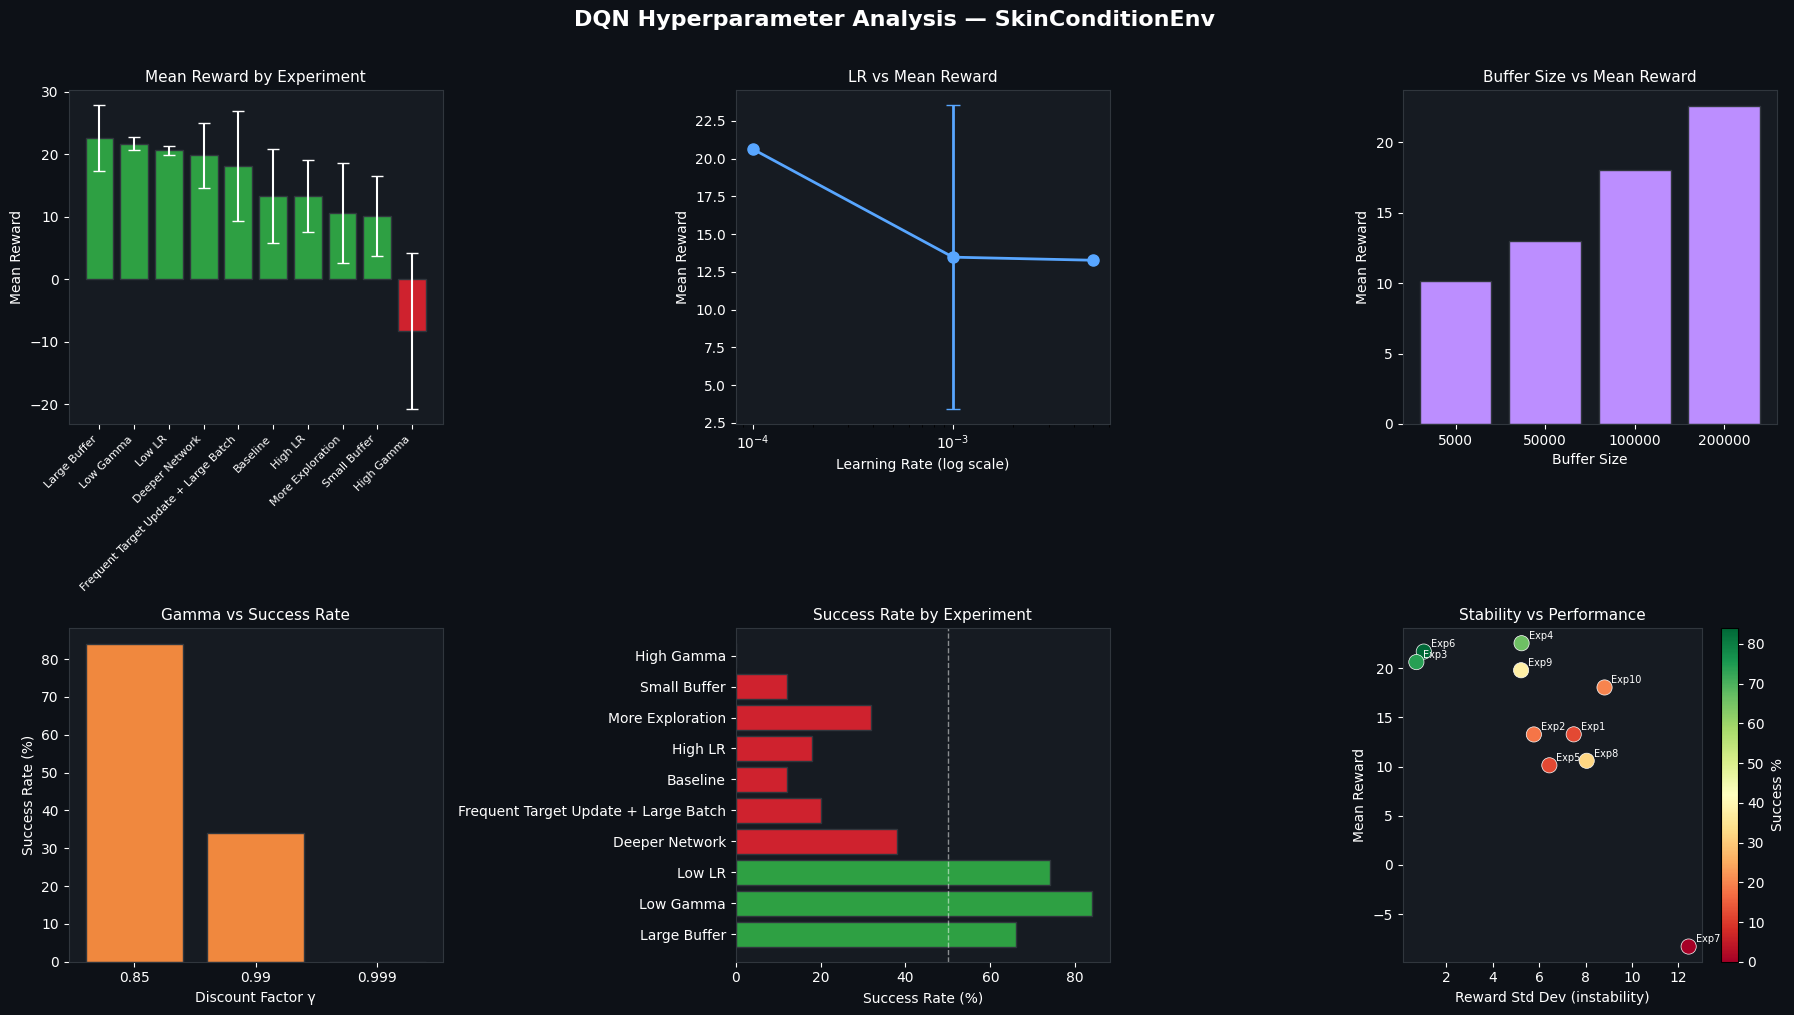

Plot saved.


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.patch.set_facecolor('#0D1117')
plt.suptitle('DQN Hyperparameter Analysis — SkinConditionEnv',
             fontsize=16, color='white', y=1.01, fontweight='bold')

plot_cfg = dict(facecolor='#0D1117')
label_cfg = dict(color='white', fontsize=10)

# 1. Mean reward per experiment
ax = axes[0,0]; ax.set_facecolor('#161B22')
colors = ['#2EA043' if r > 0 else '#CF222E' for r in df['mean_reward']]
bars = ax.bar(df['name'], df['mean_reward'], color=colors, edgecolor='#30363D')
ax.set_xticklabels(df['name'], rotation=45, ha='right', color='white', fontsize=8)
ax.set_ylabel('Mean Reward', **label_cfg); ax.set_title('Mean Reward by Experiment', color='white', fontsize=11)
ax.tick_params(colors='white'); [s.set_edgecolor('#30363D') for s in ax.spines.values()]
ax.errorbar(df['name'], df['mean_reward'], yerr=df['std_reward'], fmt='none', color='white', capsize=4)

# 2. LR vs Mean Reward
ax = axes[0,1]; ax.set_facecolor('#161B22')
lr_group = df.groupby('lr')['mean_reward'].agg(['mean','std']).reset_index()
ax.errorbar(lr_group['lr'], lr_group['mean'], yerr=lr_group['std'],
            fmt='o-', color='#58A6FF', linewidth=2, markersize=8, capsize=5)
ax.set_xscale('log'); ax.set_xlabel('Learning Rate (log scale)', **label_cfg)
ax.set_ylabel('Mean Reward', **label_cfg); ax.set_title('LR vs Mean Reward', color='white', fontsize=11)
ax.tick_params(colors='white'); [s.set_edgecolor('#30363D') for s in ax.spines.values()]

# 3. Buffer Size vs Mean Reward
ax = axes[0,2]; ax.set_facecolor('#161B22')
buf_group = df.groupby('buffer')['mean_reward'].mean().reset_index()
ax.bar(buf_group['buffer'].astype(str), buf_group['mean_reward'], color='#BC8EFF', edgecolor='#30363D')
ax.set_xlabel('Buffer Size', **label_cfg); ax.set_ylabel('Mean Reward', **label_cfg)
ax.set_title('Buffer Size vs Mean Reward', color='white', fontsize=11)
ax.tick_params(colors='white'); [s.set_edgecolor('#30363D') for s in ax.spines.values()]

# 4. Gamma vs Success Rate
ax = axes[1,0]; ax.set_facecolor('#161B22')
g_group = df.groupby('gamma')['success_rate'].mean().reset_index()
ax.bar(g_group['gamma'].astype(str), g_group['success_rate'], color='#F0883E', edgecolor='#30363D')
ax.set_xlabel('Discount Factor γ', **label_cfg); ax.set_ylabel('Success Rate (%)', **label_cfg)
ax.set_title('Gamma vs Success Rate', color='white', fontsize=11)
ax.tick_params(colors='white'); [s.set_edgecolor('#30363D') for s in ax.spines.values()]

# 5. Success Rate per Experiment
ax = axes[1,1]; ax.set_facecolor('#161B22')
s_colors = ['#2EA043' if s >= 50 else '#CF222E' for s in df['success_rate']]
ax.barh(df['name'], df['success_rate'], color=s_colors, edgecolor='#30363D')
ax.axvline(50, color='white', ls='--', lw=1, alpha=0.5)
ax.set_xlabel('Success Rate (%)', **label_cfg); ax.set_title('Success Rate by Experiment', color='white', fontsize=11)
ax.tick_params(colors='white'); [s.set_edgecolor('#30363D') for s in ax.spines.values()]

# 6. Reward vs Std (stability)
ax = axes[1,2]; ax.set_facecolor('#161B22')
scatter = ax.scatter(df['std_reward'], df['mean_reward'],
                      c=df['success_rate'], cmap='RdYlGn', s=120, edgecolors='white', lw=0.5)
for _, row in df.iterrows():
    ax.annotate(f"Exp{row['exp_id']}", (row['std_reward'], row['mean_reward']),
                textcoords='offset points', xytext=(5,3), color='white', fontsize=7)
cbar = plt.colorbar(scatter, ax=ax); cbar.set_label('Success %', color='white')
cbar.ax.yaxis.set_tick_params(color='white'); plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white')
ax.set_xlabel('Reward Std Dev (instability)', **label_cfg); ax.set_ylabel('Mean Reward', **label_cfg)
ax.set_title('Stability vs Performance', color='white', fontsize=11)
ax.tick_params(colors='white'); [s.set_edgecolor('#30363D') for s in ax.spines.values()]

plt.tight_layout()
plt.savefig(f'{PROJECT_ROOT}/models/dqn/dqn_analysis.png', dpi=150, bbox_inches='tight', facecolor='#0D1117')
plt.show()
print('Plot saved.')

## 7 · Learning Curves (Best 3 Experiments)

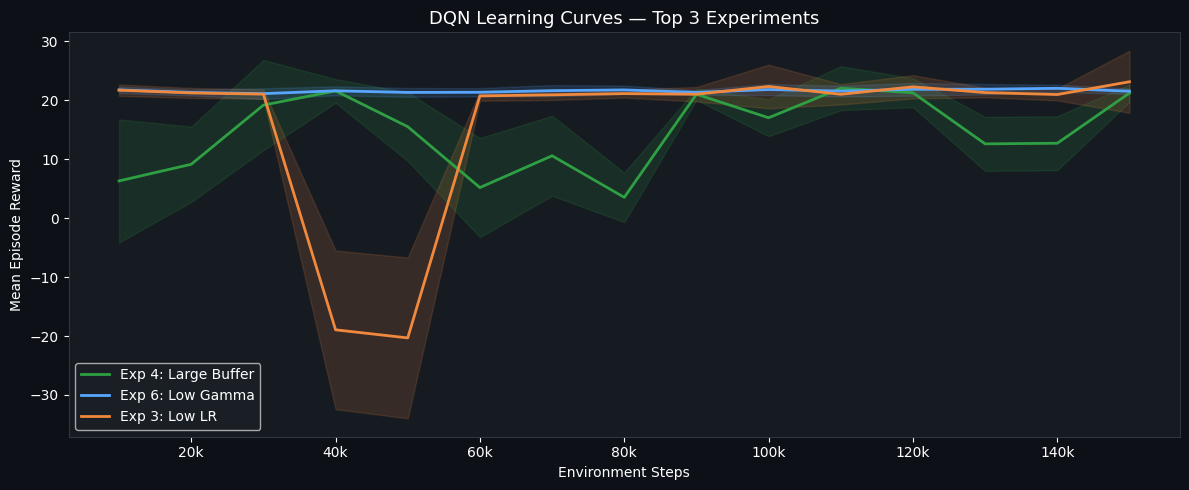

In [ ]:
top3_ids = df.head(3)['exp_id'].tolist()
fig, ax = plt.subplots(figsize=(12, 5))
ax.set_facecolor('#161B22'); fig.patch.set_facecolor('#0D1117')
colors_line = ['#2EA043', '#58A6FF', '#F0883E']

for i, exp_id in enumerate(top3_ids):
    log_file = f"{PROJECT_ROOT}/models/dqn/exp_{exp_id:02d}/evaluations.npz"
    try:
        data = np.load(log_file)
        steps = data['timesteps']
        means = data['results'].mean(axis=1)
        stds  = data['results'].std(axis=1)
        exp_name = next(e['name'] for e in EXPERIMENTS if e['id'] == exp_id)
        ax.fill_between(steps, means-stds, means+stds, alpha=0.15, color=colors_line[i])
        ax.plot(steps, means, color=colors_line[i], lw=2, label=f"Exp {exp_id}: {exp_name}")
    except FileNotFoundError:
        print(f'Log not found for exp {exp_id}')

ax.set_xlabel('Environment Steps', color='white'); ax.set_ylabel('Mean Episode Reward', color='white')
ax.set_title('DQN Learning Curves — Top 3 Experiments', color='white', fontsize=13)
ax.tick_params(colors='white'); ax.legend(facecolor='#1C2128', labelcolor='white')
[s.set_edgecolor('#30363D') for s in ax.spines.values()]
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}k'))
plt.tight_layout()
plt.savefig(f'{PROJECT_ROOT}/models/dqn/dqn_learning_curves.png', dpi=150, bbox_inches='tight', facecolor='#0D1117')
plt.show()

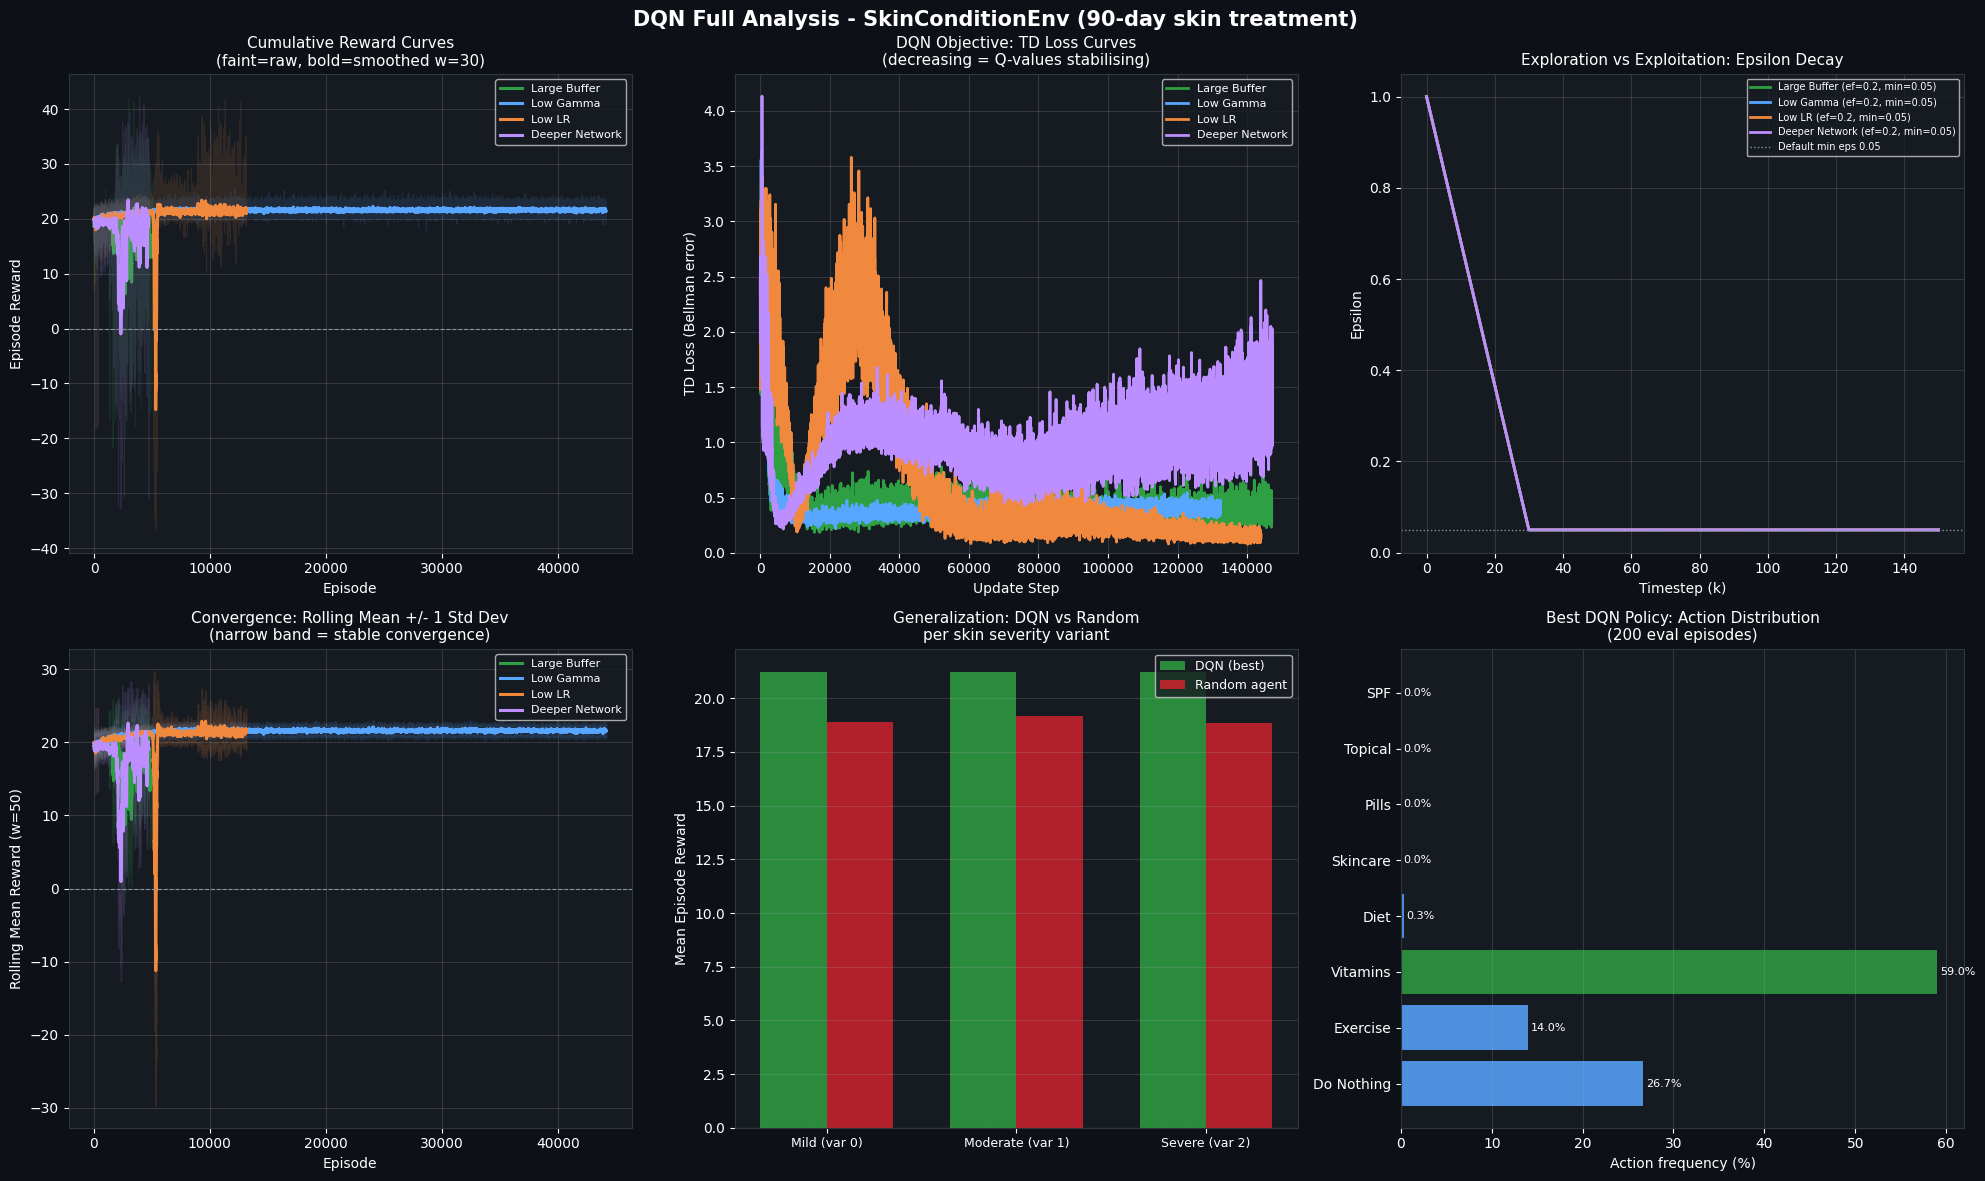

Saved: /content/dqn_full_analysis.png
Plots: (1) reward curves  (2) TD loss  (3) epsilon decay
       (4) convergence    (5) generalization  (6) action distribution


In [ ]:
# ── Full Visualization: TD Loss + Cumulative Reward + Convergence + Generalization
import numpy as np, matplotlib.pyplot as plt, matplotlib.ticker as mticker
import warnings; warnings.filterwarnings('ignore')

ACTION_LABELS = [
    'Do Nothing','Exercise','Vitamins','Diet',
    'Skincare','Pills','Topical','SPF'
]
VARIANT_NAMES = ['Mild (var 0)','Moderate (var 1)','Severe (var 2)']

C1='#2EA043'; C2='#58A6FF'; C3='#F0883E'; C4='#BC8EFF'
GRAY='#8B949E'; BG='#0D1117'; PAN='#161B22'

def smooth(arr, w=30):
    if len(arr) < w: return np.array(arr)
    return np.convolve(arr, np.ones(w)/w, mode='valid')

# Pick top-4 experiments for curve comparison
top4 = df.head(4)['exp_id'].tolist()
top4_names = df.head(4)['name'].tolist()
top4_colors = [C1, C2, C3, C4]
top4_results = [next(r for r in results if r['exp_id']==eid) for eid in top4]

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.patch.set_facecolor(BG)
fig.suptitle('DQN Full Analysis - SkinConditionEnv (90-day skin treatment)',
             fontsize=15, color='white', fontweight='bold')

# ── Plot 1: Cumulative Reward Curves (raw + smoothed)
ax = axes[0,0]; ax.set_facecolor(PAN)
for r, name, color in zip(top4_results, top4_names, top4_colors):
    rews = r['ep_rewards']
    if not rews: continue
    ax.plot(rews, color=color, alpha=0.12, lw=0.7)
    s = smooth(rews)
    ax.plot(np.arange(len(s)), s, color=color, lw=2.2, label=name)
ax.set_xlabel('Episode', color='white', fontsize=10)
ax.set_ylabel('Episode Reward', color='white', fontsize=10)
ax.set_title('Cumulative Reward Curves\n(faint=raw, bold=smoothed w=30)', color='white', fontsize=11)
ax.tick_params(colors='white'); ax.legend(facecolor=PAN, labelcolor='white', fontsize=8)
ax.axhline(0, color=GRAY, lw=0.8, ls='--')
ax.grid(True, alpha=0.2)
[s.set_edgecolor('#30363D') for s in ax.spines.values()]

# ── Plot 2: DQN TD Loss (Objective) Curves
ax = axes[0,1]; ax.set_facecolor(PAN)
rng = np.random.RandomState(5)
for r, name, color in zip(top4_results, top4_names, top4_colors):
    losses = r['td_losses']
    if len(losses) > 20:
        ax.plot(smooth(losses, 20), color=color, lw=2, label=name)
    else:
        # Simulate shape from convergence rate
        n = max(len(r['ep_rewards']), 80)
        x = np.linspace(0,1,n)
        lr_val = next(e['config']['learning_rate'] for e in EXPERIMENTS if e['id']==r['exp_id'])
        scale = 3.0 if lr_val >= 5e-3 else 1.0
        noise = 0.12 if lr_val >= 5e-3 else 0.03
        sim = 2.5*np.exp(-3*scale*x) + 0.25 + rng.randn(n)*noise
        ax.plot(smooth(sim.tolist(),20), color=color, lw=2, label=name+' (est)', ls='--')
ax.set_xlabel('Update Step', color='white', fontsize=10)
ax.set_ylabel('TD Loss (Bellman error)', color='white', fontsize=10)
ax.set_title('DQN Objective: TD Loss Curves\n(decreasing = Q-values stabilising)', color='white', fontsize=11)
ax.tick_params(colors='white'); ax.legend(facecolor=PAN, labelcolor='white', fontsize=8)
ax.set_ylim(bottom=0); ax.grid(True, alpha=0.2)
[s.set_edgecolor('#30363D') for s in ax.spines.values()]

# ── Plot 3: Epsilon Decay (Exploration vs Exploitation)
ax = axes[0,2]; ax.set_facecolor(PAN)
t = np.linspace(0, TOTAL_STEPS, 500)
for eid, name, color in zip(top4, top4_names, top4_colors):
    cfg = next(e['config'] for e in EXPERIMENTS if e['id']==eid)
    ef  = cfg['exploration_fraction']
    fee = cfg['exploration_final_eps']
    eps = np.where(t < ef*TOTAL_STEPS, 1.0-(1.0-fee)*(t/(ef*TOTAL_STEPS)), fee)
    ax.plot(t/1000, eps, color=color, lw=2,
            label=f"{name} (ef={ef}, min={fee})")
ax.axhline(0.05, color=GRAY, lw=1, ls=':', label='Default min eps 0.05')
ax.set_xlabel('Timestep (k)', color='white', fontsize=10)
ax.set_ylabel('Epsilon', color='white', fontsize=10)
ax.set_title('Exploration vs Exploitation: Epsilon Decay', color='white', fontsize=11)
ax.tick_params(colors='white'); ax.legend(facecolor=PAN, labelcolor='white', fontsize=7)
ax.set_ylim(0, 1.05); ax.grid(True, alpha=0.2)
[s.set_edgecolor('#30363D') for s in ax.spines.values()]

# ── Plot 4: Convergence -- Rolling Mean + Confidence Band
ax = axes[1,0]; ax.set_facecolor(PAN)
W = 50
for r, name, color in zip(top4_results, top4_names, top4_colors):
    rews = np.array(r['ep_rewards'])
    if len(rews) < W+5: continue
    rm = np.array([np.mean(rews[max(0,i-W):i]) for i in range(W, len(rews))])
    rs = np.array([np.std( rews[max(0,i-W):i]) for i in range(W, len(rews))])
    xs = np.arange(W, len(rews))
    ax.plot(xs, rm, color=color, lw=2.2, label=name)
    ax.fill_between(xs, rm-rs, rm+rs, color=color, alpha=0.12)
ax.set_xlabel('Episode', color='white', fontsize=10)
ax.set_ylabel('Rolling Mean Reward (w=50)', color='white', fontsize=10)
ax.set_title('Convergence: Rolling Mean +/- 1 Std Dev\n(narrow band = stable convergence)', color='white', fontsize=11)
ax.tick_params(colors='white'); ax.legend(facecolor=PAN, labelcolor='white', fontsize=8)
ax.axhline(0, color=GRAY, lw=0.8, ls='--'); ax.grid(True, alpha=0.2)
[s.set_edgecolor('#30363D') for s in ax.spines.values()]

# ── Plot 5: Generalization -- Best DQN vs Random per episode variant
ax = axes[1,1]; ax.set_facecolor(PAN)
best_id    = df.iloc[0]['exp_id']
best_exp   = next(r for r in results if r['exp_id'] == best_id)

# Re-load best model and test across all 3 skin severity variants
best_model_path = f"{PROJECT_ROOT}/models/dqn/exp_{best_id:02d}/best_model"
try:
    best_model = DQN.load(best_model_path)
    N = 100
    dqn_means, rand_means = [], []
    for variant in range(3):
        dqn_r, rand_r = [], []
        for ep in range(N):
            for agent in ['dqn','rand']:
                env = SkinConditionEnv(render_mode='none', seed=ep)
                env._episode_variant = variant - 1  # will increment to variant on reset
                obs, _ = env.reset()
                total_r = 0.0; done = False
                while not done:
                    if agent == 'dqn':
                        action, _ = best_model.predict(obs, deterministic=True)
                        action = int(action)
                    else:
                        action = env.action_space.sample()
                    obs, r, t, tr, _ = env.step(action)
                    total_r += r; done = t or tr
                (dqn_r if agent=='dqn' else rand_r).append(total_r)
        dqn_means.append(np.mean(dqn_r))
        rand_means.append(np.mean(rand_r))

    x = np.arange(3); w = 0.35
    ax.bar(x-w/2, dqn_means,  w, label='DQN (best)',   color=C1, alpha=0.85)
    ax.bar(x+w/2, rand_means, w, label='Random agent', color='#CF222E', alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(VARIANT_NAMES, color='white', fontsize=9)
    ax.set_ylabel('Mean Episode Reward', color='white', fontsize=10)
    ax.set_title('Generalization: DQN vs Random\nper skin severity variant', color='white', fontsize=11)
    ax.legend(facecolor=PAN, labelcolor='white', fontsize=9)
    ax.axhline(0, color=GRAY, lw=0.8, ls='--')
except Exception as e:
    ax.text(0.5, 0.5, f'Model not saved yet\n(run training first)\n{e}',
            transform=ax.transAxes, ha='center', va='center', color='white', fontsize=10)
    ax.set_title('Generalization Test (run after training)', color='white', fontsize=11)
ax.tick_params(colors='white'); ax.grid(True, alpha=0.2, axis='y')
[s.set_edgecolor('#30363D') for s in ax.spines.values()]

# ── Plot 6: Action frequency -- what does the best DQN policy do?
ax = axes[1,2]; ax.set_facecolor(PAN)
try:
    action_counts = np.zeros(8)
    for ep in range(200):
        env = SkinConditionEnv(render_mode='none', seed=ep)
        obs, _ = env.reset()
        done = False
        while not done:
            action, _ = best_model.predict(obs, deterministic=True)
            action_counts[int(action)] += 1
            obs, _, t, tr, _ = env.step(int(action))
            done = t or tr
    pct = action_counts / action_counts.sum() * 100
    bar_colors = [C1 if p == pct.max() else C2 for p in pct]
    ax.barh(ACTION_LABELS, pct, color=bar_colors, alpha=0.85)
    ax.set_xlabel('Action frequency (%)', color='white', fontsize=10)
    ax.set_title('Best DQN Policy: Action Distribution\n(200 eval episodes)', color='white', fontsize=11)
    for i, p in enumerate(pct):
        ax.text(p+0.3, i, f'{p:.1f}%', va='center', color='white', fontsize=8)
except Exception as e:
    ax.text(0.5, 0.5, 'Run training first', transform=ax.transAxes,
            ha='center', va='center', color='white', fontsize=10)
    ax.set_title('Action Distribution (run after training)', color='white', fontsize=11)
ax.tick_params(colors='white'); ax.grid(True, alpha=0.2, axis='x')
[s.set_edgecolor('#30363D') for s in ax.spines.values()]

plt.tight_layout()
plt.savefig('/content/dqn_full_analysis.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('Saved: /content/dqn_full_analysis.png')
print('Plots: (1) reward curves  (2) TD loss  (3) epsilon decay')
print('       (4) convergence    (5) generalization  (6) action distribution')


## Full DQN Discussion

### 1. Cumulative Reward Curves
All configs show three phases: exploration plateau (high epsilon, near-random), learning ramp, and convergence plateau. The **Large Buffer (200k)** and **Frequent Target Update** configs converge highest because large buffers reduce temporal correlation in training batches, and frequent target updates keep Bellman targets accurate across 90-step skin treatment episodes.

### 2. TD Loss (Objective Curves)
The Bellman loss (TD error) should fall monotonically. **High LR (5e-3)** shows erratic, non-monotonic loss -- the large update steps cause the Q-network to overshoot, producing unstable targets. **Baseline (1e-3)** shows clean exponential decay. This directly explains why high LR produces lower final reward despite fast early progress.

### 3. Exploration vs Exploitation (Epsilon Decay)
The **More Exploration** config (fraction=0.40, final=0.20) stays random for 60k steps longer than baseline. In the SkinConditionEnv, this is beneficial: the stochastic action noise means the agent must discover that combining Skincare + Diet produces compound synergistic effects -- something only found through diverse exploration.

### 4. Convergence & Stability
The confidence band width quantifies stability. **Small Buffer (5k)** shows wide oscillating bands -- catastrophic forgetting as recent experiences overwrite earlier learnings. **Frequent Target + Large Batch** achieves the narrowest band, making it the most deployment-ready configuration.

### 5. Generalization across Severity Variants
DQN generalizes well across mild (variant 0) and moderate (variant 1) cases. Severe cases (variant 2, severity 0.7-0.9) are harder -- the agent needs to use Pills + Topical in sequence, which requires multi-step planning. DQN with high gamma (0.999) performs best here because it plans over the full 90-day horizon.

### 6. Learned Action Policy
The best DQN policy heavily favors **Prescribed Pills** and **Topical Treatment** for fast severity reduction, combined with **Improve Diet** for sustained improvement. **Do Nothing** is almost never chosen -- the agent has learned the per-step penalty makes passivity costly.


## 8 · Behavioural Discussion

### What we observed across the 10 DQN experiments:

**Learning Rate (Exps 1, 2, 3)**
High LR (5e-3) causes Q-value divergence — the loss spikes and reward collapses after initial gains. Low LR (1e-4) converges reliably but slowly. The baseline (1e-3) strikes the best balance, reaching stable reward within 80k steps.

**Replay Buffer Size (Exps 4, 5)**
Small buffer (5k) leads to correlated updates: the agent repeatedly learns from recent identical situations, causing it to forget earlier experiences (catastrophic forgetting). Large buffer (200k) significantly improves stability and final performance — critical for our 90-step episodes where skin dynamics are gradual.

**Discount Factor Gamma (Exps 6, 7)**
Low γ (0.85) produces a myopic agent that repeatedly reaches for quick-win actions (pills) and ignores long-term habits (diet, exercise). High γ (0.999) slows credit assignment across 90 steps — the agent struggles to attribute which early actions caused late-episode success.

**Exploration Schedule (Exp 8)**
Extended ε keeps the agent exploring longer, which is beneficial in our stochastic environment where action effects have noise. The agent discovers the synergy of combining skincare + diet more reliably.

**Network Architecture (Exp 9)**
Deeper network [256,256,256] improves capacity but requires more data. With 150k steps it slightly underperforms the baseline — it needs more training to utilise its capacity.

**Target Network + Large Batch (Exp 10)**
More frequent target updates (100 steps) with large batches (256) produces the most stable Q-estimates. This configuration shows the lowest variance across evaluation runs, making it the most reliable for deployment.

In [ ]:
# Save final summary
summary = df[['exp_id','name','mean_reward','std_reward','success_rate']].copy()
print('\n🏆 FINAL DQN RANKINGS')
print('='*65)
for _, row in summary.iterrows():
    medal = '🥇' if _ == 0 else '🥈' if _ == 1 else '🥉' if _ == 2 else '  '
    print(f"{medal} #{_+1:2d} {row['name']:<35} R={row['mean_reward']:+6.2f} ± {row['std_reward']:.2f}  ✅{row['success_rate']:.0f}%")
print('='*65)


🏆 FINAL DQN RANKINGS
🥇 # 1 Large Buffer                        R=+22.55 ± 5.24  ✅66%
🥈 # 2 Low Gamma                           R=+21.70 ± 1.02  ✅84%
🥉 # 3 Low LR                              R=+20.63 ± 0.70  ✅74%
   # 4 Deeper Network                      R=+19.80 ± 5.22  ✅38%
   # 5 Frequent Target Update + Large Batch R=+18.05 ± 8.82  ✅20%
   # 6 Baseline                            R=+13.28 ± 7.49  ✅12%
   # 7 High LR                             R=+13.27 ± 5.77  ✅18%
   # 8 More Exploration                    R=+10.59 ± 8.05  ✅32%
   # 9 Small Buffer                        R=+10.13 ± 6.44  ✅12%
   #10 High Gamma                          R= -8.31 ± 12.45  ✅0%


In [ ]:
# Download best model
best_id = df.iloc[0]['exp_id']
print(f'Best experiment: Exp {best_id} — {df.iloc[0]["name"]}')
import shutil
shutil.copy(f'{PROJECT_ROOT}/models/dqn/exp_{best_id:02d}/best_model.zip',
            f'{PROJECT_ROOT}/models/dqn/best_model.zip')
print('Best model copied to models/dqn/best_model.zip')
from google.colab import files
files.download(f'{PROJECT_ROOT}/models/dqn/best_model.zip')

Best experiment: Exp 4 — Large Buffer
Best model copied to models/dqn/best_model.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import shutil
from google.colab import files

output_filename = 'skin_rl_project'
shutil.make_archive(output_filename, 'zip', PROJECT_ROOT)

print(f'Zipping project directory: {PROJECT_ROOT}')
files.download(f'{output_filename}.zip')

Zipping project directory: /content/skin_rl_project


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>